# LSEG full-text cash-flow-distance audit pack

This notebook prepares, but does not label or analyse returns for, the newly
feasible human validation of cash-flow distance. The source is the local
Reuters full-text subset whose normalised headline hashes occur in the
completed 888,155-headline Gemma population.

## Frozen design

- Estimand: inter-coder reliability and later criterion validity of a 0–3
  distance-from-realised-cash-flow construct.
- Population: unique normalised headlines with non-empty Reuters full text
  and a successful Gemma score hash.
- Sampling: 200 events, stratified by a return-blind lexical enrichment rule;
  35/35/35/60/35 from proxy strata 0/1/2/3/unmatched.
- Reliability subset: 60 events, 12 from each stratum, independently ordered
  for coder B.
- Blinding: coder sheets contain text and blank coding fields only. They omit
  sentiment, proxy stratum, hash, company/date metadata, and all returns.
- Return gate: no return model using these labels may be opened unless
  quadratic-weighted kappa is at least 0.60, its 95% event-bootstrap lower
  bound is at least 0.40, and adjacent agreement is at least 0.80.
- `NA` handling: ordinal kappa excludes pairs containing `NA`; at least 48
  of 60 pairs must be jointly numeric. Exact/adjacent agreement use all 60.
  The event bootstrap uses 9,999 resamples with seed 20260819.

The machine strata are sampling aids, not validated labels. Licensed text
stays under the ignored `outputs/` boundary.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.cash_flow_audit import (  # noqa: E402
    AUDIT_ALLOCATION,
    AUDIT_SEED,
    build_blinded_audit_sample,
    load_full_text_candidates,
    write_audit_pack,
)
from final_experiments.lib.lseg_expanded import load_success_scores  # noqa: E402

COLLECTION_ROOT = REPO_ROOT / "Data/collections/lseg_us_sector_44_8m_headlines/derived"
GEMMA_SCORES = COLLECTION_ROOT / (
    "headline_scores_gemma4_26b_a4b_it_deepinfra_fp8_"
    "investor_headline_soft_label_v1.csv"
)
ARTICLES = REPO_ROOT / (
    "Data/collections/lseg_us_sector_33_6m/derived/"
    "us_sector_33_6m/articles.jsonl"
)
OUTPUT = REPO_ROOT / "final_experiments/outputs/16_lseg_cash_flow_distance_audit"
OUTPUT.mkdir(parents=True, exist_ok=True)

print("design: return-blind human validation pack; no return analysis")
print("allocation:", AUDIT_ALLOCATION)
print("seed:", AUDIT_SEED)
print("licence boundary:", OUTPUT.relative_to(REPO_ROOT))

design: return-blind human validation pack; no return analysis
allocation: {'d0': 35, 'd1': 35, 'd2': 35, 'd3': 60, 'unmatched': 35}
seed: 20260805
licence boundary: final_experiments/outputs/16_lseg_cash_flow_distance_audit


## Validate the successful score population and full-text source

`load_success_scores` verifies the completed Gemma manifest, DeepInfra FP8
contract, output hash, one-success-per-headline coverage, and probabilities.
Headline text is not loaded from the score file.

In [2]:
gemma, score_audit = load_success_scores(GEMMA_SCORES, scorer="gemma4_26b")
eligible_hashes = set(gemma["headline_sha256"].astype(str))
del gemma

candidates, source_audit = load_full_text_candidates(
    ARTICLES,
    eligible_hashes=eligible_hashes,
)
del eligible_hashes

source_summary = pd.DataFrame(
    [
        {"measure": "successful Gemma hashes", "count": score_audit["unique_successes"]},
        {"measure": "article rows read", "count": source_audit["rows_read"]},
        {
            "measure": "rows with non-empty full text",
            "count": source_audit["rows_with_nonempty_full_text"],
        },
        {
            "measure": "full-text rows matching Gemma hashes",
            "count": source_audit["rows_matching_successful_gemma_hashes"],
        },
        {
            "measure": "unique matching headline hashes",
            "count": source_audit["unique_matching_headline_hashes"],
        },
    ]
)
display(source_summary)
display(
    pd.Series(source_audit["candidate_stratum_counts"], name="candidate_count")
    .rename_axis("proxy_stratum")
    .reset_index()
)

,measure,count
0,successful Gemma hashes,888155
1,article rows read,710625
2,rows with non-empty full text,17511
3,full-text rows matching Gemma hashes,17508
4,unique matching headline hashes,16861


,proxy_stratum,candidate_count
0,d0,1442
1,d1,1029
2,d2,1594
3,d3,10176
4,unmatched,2620


The notebook displays counts only. It does not display or save any story text
outside the coder worksheets in the ignored local output directory.

In [3]:
coder_a, coder_b, private_key, sampling_summary = build_blinded_audit_sample(
    candidates,
    seed=AUDIT_SEED,
)
manifest = write_audit_pack(
    OUTPUT,
    coder_a=coder_a,
    coder_b=coder_b,
    private_key=private_key,
    summary=sampling_summary,
    source_audit=source_audit,
    seed=AUDIT_SEED,
    allocation=AUDIT_ALLOCATION,
)
del candidates, coder_a, coder_b, private_key

display(sampling_summary)
print("coder A rows:", manifest["sample_rows"])
print("coder B rows:", manifest["double_code_rows"])
print("status:", manifest["status"])

,proxy_stratum,candidate_count,sample_count,inclusion_probability,double_code_count
0,d0,1442,35,0.024272,12
1,d1,1029,35,0.034014,12
2,d2,1594,35,0.021957,12
3,d3,10176,60,0.005896,12
4,unmatched,2620,35,0.013359,12


coder A rows: 200
coder B rows: 60
status: prepared_unlabelled


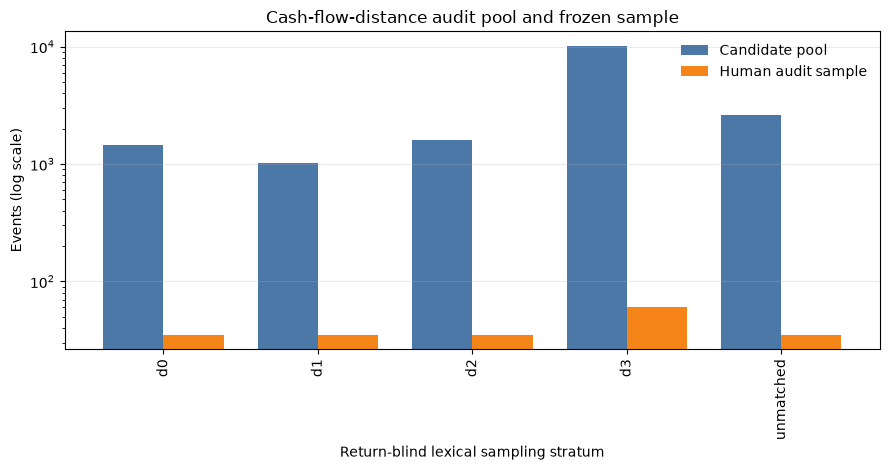

In [4]:
plot_data = sampling_summary.set_index("proxy_stratum")[[
    "candidate_count",
    "sample_count",
]]
ax = plot_data.plot.bar(
    figsize=(9, 4.8),
    color=["#4C78A8", "#F58518"],
    width=0.78,
)
ax.set_yscale("log")
ax.set_xlabel("Return-blind lexical sampling stratum")
ax.set_ylabel("Events (log scale)")
ax.set_title("Cash-flow-distance audit pool and frozen sample")
ax.legend(["Candidate pool", "Human audit sample"], frameon=False)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT / "audit_sampling_counts.png", dpi=160, bbox_inches="tight")
plt.show()

## Integrity checks and hand-off

The two worksheets are unlabelled. Coder A labels all 200 events and coder B
independently labels the 60-event overlap using
`final_experiments/data/cash_flow_distance_codebook.md`. The private key is
opened only after both files are complete. The frozen gate is quadratic-
weighted kappa ≥ 0.60, its 95% event-bootstrap lower bound ≥ 0.40, and
adjacent agreement ≥ 0.80. Exact agreement, confusion, and adjudication are
also reported before any human-distance × sentiment return model is specified.
Immutable ID/headline/body hashes bind both worksheets to this sample while
allowing coding fields to change. Do not rerun this preparation notebook once
coding starts; Notebook 62 reads and validates the labelled files in place.

In [5]:
assert manifest["sample_rows"] == 200
assert manifest["double_code_rows"] == 60
assert manifest["blinding"]["machine_stratum_visible_to_coders"] is False
assert manifest["blinding"]["sentiment_visible_to_coders"] is False
assert manifest["blinding"]["returns_visible_to_coders"] is False
assert set(manifest["worksheet_identity_sha256"]) == {
    "coder_a_200.csv",
    "coder_b_double_code_60.csv",
}
assert sampling_summary["sample_count"].sum() == 200
assert sampling_summary["double_code_count"].sum() == 60

safe_manifest = {
    "status": manifest["status"],
    "sample_rows": manifest["sample_rows"],
    "double_code_rows": manifest["double_code_rows"],
    "allocation": manifest["allocation"],
    "blinding": manifest["blinding"],
    "worksheet_identities_frozen": sorted(manifest["worksheet_identity_sha256"]),
    "source_counts": {
        key: value
        for key, value in source_audit.items()
        if key not in {"articles_sha256"}
    },
}
print(json.dumps(safe_manifest, indent=2))

{
  "status": "prepared_unlabelled",
  "sample_rows": 200,
  "double_code_rows": 60,
  "allocation": {
    "d0": 35,
    "d1": 35,
    "d2": 35,
    "d3": 60,
    "unmatched": 35
  },
  "blinding": {
    "omitted_from_coder_sheets": [
      "ar_open_h1",
      "headline_sha256",
      "label",
      "matched_symbols",
      "proxy_cash_flow_distance",
      "proxy_stratum",
      "raw_open_h1",
      "return",
      "score",
      "version_created"
    ],
    "machine_stratum_visible_to_coders": false,
    "sentiment_visible_to_coders": false,
    "returns_visible_to_coders": false
  },
  "worksheet_identities_frozen": [
    "coder_a_200.csv",
    "coder_b_double_code_60.csv"
  ],
  "source_counts": {
    "rows_read": 710625,
    "rows_with_nonempty_full_text": 17511,
    "rows_matching_successful_gemma_hashes": 17508,
    "unique_matching_headline_hashes": 16861,
    "candidate_stratum_counts": {
      "d0": 1442,
      "d1": 1029,
      "d2": 1594,
      "d3": 10176,
      "unmatched

**Status:** audit pack prepared, human labels outstanding. This unblocks data
collection for construct validation; it does not rehabilitate Notebook 14's
failed machine-proxy strategy and does not authorise return-driven tuning.
The next executable step is Notebook 62 after independent coding.